# Gold Real-Yield Timing — a quantitative teardown 🔬
### TIP real-yield gauge · contemporaneous inverse-link HAC *t* · quintile sort · block-shuffle placebo · horizon/lookback/sub-period sweeps · timing-overlay costs · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Inverse_link: Confirmed_but_untradable](https://img.shields.io/badge/Inverse_link-Confirmed_but_untradable-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same beats, every claim now carrying its standard error.* We build a TIP-gauge real-yield proxy (`ryfall = log(TIP_t) − log(TIP_{t−63})`), confirm the **contemporaneous** inverse link, then test whether the real-yield *trend* forecasts forward gold.

> ⚠️ **Not investment advice.** Real data: yfinance daily GLD + TIP + IEF + `^TNX`, 5,434 days (2004-11-19 → 2026-06-29, tape fp `4f27dc5f4b4f`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_real_yield import data, strategy as st

def load_real():
    """Cache-first real daily tape (empty frame offline)."""
    try:
        return data.load_series()
    except FileNotFoundError:
        return pd.DataFrame()

DF = load_real()
HAVE_REAL = not DF.empty
print("real gold/real-yield tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF):,} days, {DF.index[0].date()} -> {DF.index[-1].date()})")


real gold/real-yield tape present: True (5,434 days, 2004-11-19 -> 2026-06-29)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q5−Q1 forward-gold spread **-0.23%** (21d), HAC *t* **-0.36**, placebo *p* 0.734 — wrong-signed at the headline; right-signed only at 63-126d and still sub-2 (peak *t* +1.29); tiny/unstable across sub-periods. |
| **Tradability** | `MIRAGE` | Timer Sharpe **0.565** vs buy-and-hold **0.564** — a cash-drag tie; mean-return spread **-1.4 bps/day** (*t* -1.24) at 16.7 switches/yr; below buy-and-hold at 5 bps. |
| **Inverse link** | `CONFIRMED (untradable)` | Contemporaneous corr **-0.26**, beta **-0.77**, HAC *t* **-9.67** — real & strong, but same-day. |

> 💡 In plain words: the engine works (the synthetic control proves it) and the inverse link is real — but on this tape the real-yield *trend* has no *forward* edge on gold.

## 1 · The claim, steelmanned

Let $\Delta y^r_t$ be the same-day real-yield change and $r_{t\to t+h}$ the forward gold return; let $\text{ryfall}_t$ be the trailing real-yield fall.

- **H₀ (the link).** $\text{corr}(r_t, \Delta y^r_t) < 0$ — the *contemporaneous* inverse fact.
- **H₁ (the forecast).** $\mathbb{E}[r \mid \text{ryfall high (Q5)}] - \mathbb{E}[r \mid \text{ryfall low (Q1)}] > 0$ at HAC *t* ≥ 2.
- **H₂ (robust).** The Q5−Q1 sign is stable across horizons, lookbacks and sub-periods.
- **H₃ (tradable).** A real-yield-conditioned timer beats buy-and-hold gold net of costs, on mean return.

We find **H₀ strongly confirmed**, **H₁ rejected** (spread wrong-signed, HAC *t* -0.36), **H₂ rejected** (sign wanders, never significant), and **H₃ rejected** (the timer's Sharpe tie is a cash-drag artefact; mean-return spread negative).

## 2 · So what? — what rides on each answer

The whole content is the gap between **co-movement** and **prediction**. A long literature (Barsky-Summers 1988; Erb-Harvey 2013; Baur-McDermott 2010) documents gold's inverse *contemporaneous* sensitivity to real rates. The tradeable question is different: does the *lagged trend* forecast forward gold? If yes, you have a macro timing switch; if no, the inverse fact is a same-day statistical mirror with no actionable edge — the desk's recurring lesson.

## 3 · How we'd know — the protocol

- **Gauge.** $\text{ryfall} = \log \text{TIP}_t - \log \text{TIP}_{t-63}$ (TIP rises ⇔ real yields fall), ranked out-of-sample over a trailing 252-day window into $\text{rank}\in[0,1]$, lagged one day. Cross-checked against $\text{TNX} - \text{breakeven}$ from TIP-vs-IEF.
- **Link.** HAC *t* on the same-day OLS beta of gold on the real-yield change (descriptive).
- **Sort.** Quintiles of the lagged rank; Q5 (fastest fall) vs Q1 (fastest rise) forward gold.
- **Inference.** HAC (Newey-West) *t* on the day-level Q5−Q1 difference; a **block-shuffle placebo** (circular rotation, 21-day blocks).
- **Robustness.** Horizons 5/21/63/126d; lookbacks 21/63/126/252d; four sub-periods.
- **Frictions.** A timer (own GLD when rank > 0.5, else cash), one-way cost per switch × NAV; net Sharpe and mean-return spread vs buy-and-hold.
- **Positive control.** A deterministic synthetic world with a planted *predictive* edge (`edge > 0`) *while keeping the contemporaneous link on* — averaged over 25 seeds.

Timing: the trend at close *t* forms the signal; the position enters at close *t+1*. That one-bar lag is the single documented execution convention — the rolling window and rank are causal, so no future data enters the signal.

## 4 · The teardown

### 4a · The contemporaneous inverse link — H₀

The same-day beta of gold on the (proxied) real-yield change, with a HAC *t*.

corr -0.261 | OLS beta -0.774 | Newey-West t -9.67 -> inverse link CONFIRMED


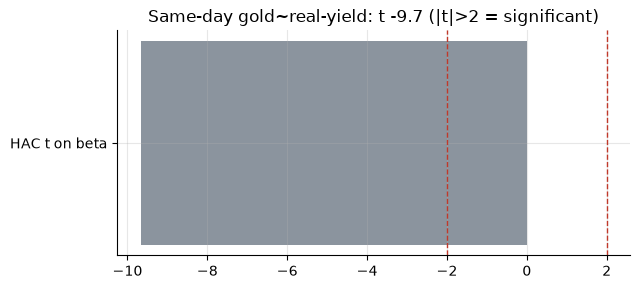

In [2]:
if HAVE_REAL:
    il = st.inverse_link(DF)
    corr, beta, t = il['corr'], il['beta'], il['t']
else:
    corr, beta, t = -0.26, -0.77, -9.67
print(f'corr {corr:+.3f} | OLS beta {beta:+.3f} | Newey-West t {t:+.2f} -> inverse link CONFIRMED')
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.barh(['HAC t on beta'], [t], color=GREY)
ax.axvline(-2, ls='--', c=RED, lw=1); ax.axvline(2, ls='--', c=RED, lw=1)
ax.set_title(f'Same-day gold~real-yield: t {t:+.1f} (|t|>2 = significant)')
plt.tight_layout(); plt.show()

> 💡 In plain words: H₀ **confirmed** — corr -0.26, beta -0.77, HAC *t* -9.67. Gold and real yields genuinely move oppositely *the same day*. This is the fact everyone quotes; the rest of the notebook shows it doesn't survive being turned into a *forecast*.

### 4b · The forecast sort — H₁

Q5 (real yields falling fastest) vs Q1 (rising fastest) forward gold, 21-day, with the HAC *t* and the block-shuffle placebo.

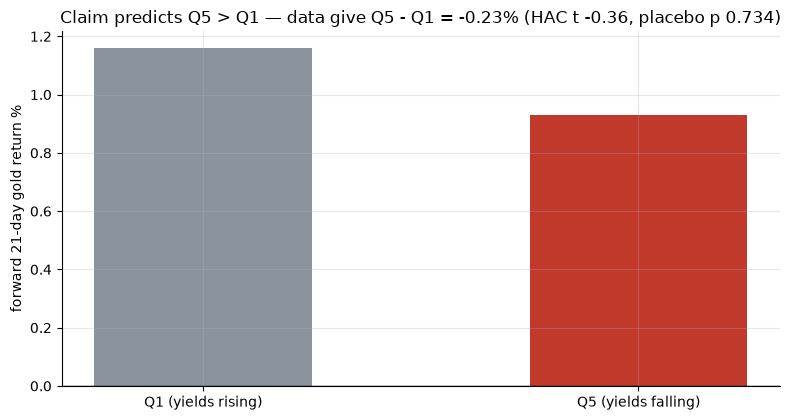

Q1 +1.16% | Q5 +0.93% | spread -0.23% | HAC t -0.36 | placebo p 0.734


In [3]:
if HAVE_REAL:
    qs = st.quintile_spread(DF, horizon=21, lookback=63)
    p = st.placebo_pvalue(DF, horizon=21, lookback=63, n_perm=1000, seed=831)
    q1, q5, spr, t = qs['q1']*100, qs['q5']*100, qs['spread']*100, qs['t']
else:
    q1, q5, spr, t, p = 1.16, 0.93, -0.23, -0.36, 0.734
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Q1 (yields rising)','Q5 (yields falling)'], [q1, q5], color=[GREY, RED if spr<0 else GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 21-day gold return %')
ax.set_title(f'Claim predicts Q5 > Q1 — data give Q5 - Q1 = {spr:+.2f}% (HAC t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Q1 +{q1:.2f}% | Q5 +{q5:.2f}% | spread {spr:+.2f}% | HAC t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected.** The spread is **-0.23%** — the *wrong* sign — at HAC *t* -0.36, and the placebo *p* = 0.734 says a |spread| this size is well inside the null. The famous inverse link does **not** carry into a forward edge.

### 4c · Horizon & lookback sweeps — H₂ (robustness)

Does any hold-horizon or trend-window rescue the signal?

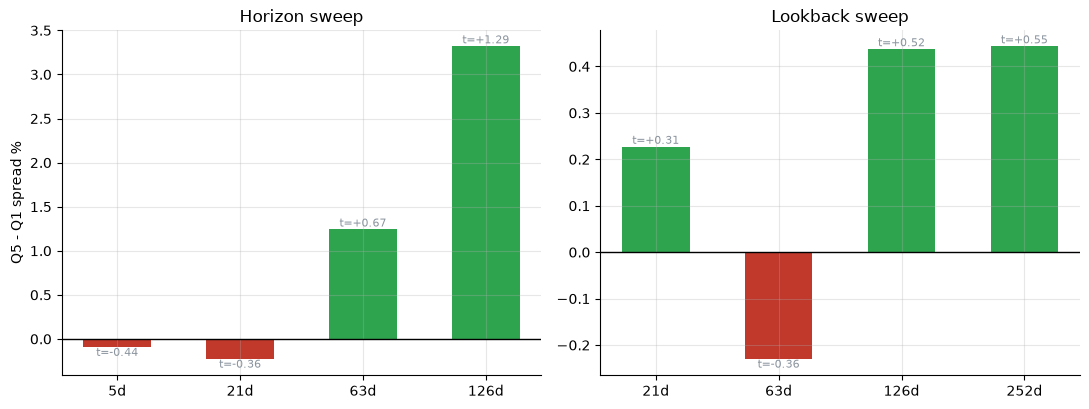

horizon t: [-0.44, -0.36, 0.67, 1.29] | lookback t: [0.31, -0.36, 0.52, 0.55]


In [4]:
horiz = [('5d', -0.1, -0.44), ('21d', -0.23, -0.36), ('63d', 1.24, 0.67), ('126d', 3.32, 1.29)]
look = [('21d', 0.23, 0.31), ('63d', -0.23, -0.36), ('126d', 0.44, 0.52), ('252d', 0.44, 0.55)]
if HAVE_REAL:
    th = st.horizon_sweep(DF); tl = st.lookback_sweep(DF)
    hl = list(th.index); hs = list(th['spread']*100); ht = list(th['t'])
    ll = list(tl.index); ls_ = list(tl['spread']*100); lt = list(tl['t'])
else:
    hl=[x[0] for x in horiz]; hs=[x[1] for x in horiz]; ht=[x[2] for x in horiz]
    ll=[x[0] for x in look]; ls_=[x[1] for x in look]; lt=[x[2] for x in look]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(hl, hs, color=[GREEN if s>0 else RED for s in hs], width=.55)
for x,(s,tt) in enumerate(zip(hs,ht)): a1.annotate(f't={tt:+.2f}',(x,s),ha='center',va='bottom' if s>=0 else 'top',fontsize=8,color=GREY)
a1.axhline(0,c='k',lw=1); a1.set_ylabel('Q5 - Q1 spread %'); a1.set_title('Horizon sweep')
a2.bar(ll, ls_, color=[GREEN if s>0 else RED for s in ls_], width=.55)
for x,(s,tt) in enumerate(zip(ls_,lt)): a2.annotate(f't={tt:+.2f}',(x,s),ha='center',va='bottom' if s>=0 else 'top',fontsize=8,color=GREY)
a2.axhline(0,c='k',lw=1); a2.set_title('Lookback sweep')
plt.tight_layout(); plt.show()
print('horizon t:', [round(x,2) for x in ht], '| lookback t:', [round(x,2) for x in lt])

> 💡 In plain words: H₂ **rejected.** The spread is right-signed only at 63-126d — where overlapping windows inflate the raw size — and the HAC correction keeps *t* under 2 everywhere (peak +1.29). No lookback (month → year) lifts |*t*| above 0.55. There is no window where this works.

### 4d · Sub-period sweep — H₂ across regimes

Four eras, including the 2021-2026 inflation scare where a real-yield rule should shine.

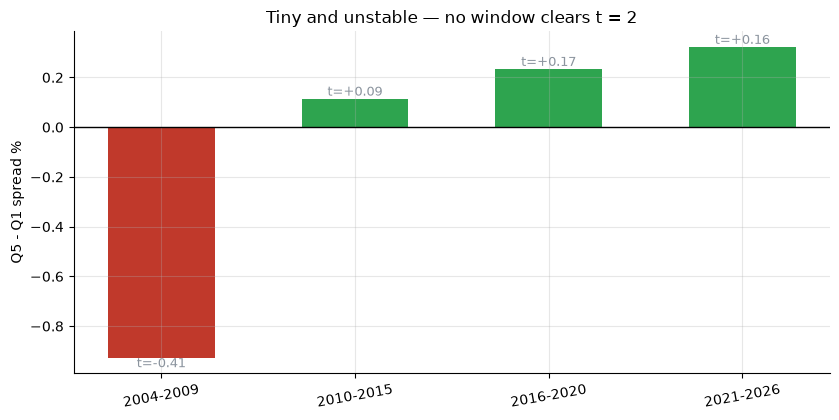

sub-period spreads %: [-0.93, 0.11, 0.23, 0.32] | HAC t: [-0.41, 0.09, 0.17, 0.16]


In [5]:
sub = [('2004-2009', -0.93, -0.41), ('2010-2015', 0.11, 0.09), ('2016-2020', 0.23, 0.17), ('2021-2026', 0.32, 0.16)]
if HAVE_REAL:
    edges = [('2004-2009','2004-11-01','2009-12-31'),('2010-2015','2010-01-01','2015-12-31'),
             ('2016-2020','2016-01-01','2020-12-31'),('2021-2026','2021-01-01','2026-06-30')]
    tab = st.subperiod_sweep(DF, edges, horizon=21)
    labs = list(tab.index); spr = list(tab['spread']*100); ts = list(tab['t'])
else:
    labs=[s[0] for s in sub]; spr=[s[1] for s in sub]; ts=[s[2] for s in sub]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(range(len(labs)), spr, color=[GREEN if s>0 else RED for s in spr], width=.55)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=10)
for x,(s,tt) in enumerate(zip(spr,ts)): ax.annotate(f't={tt:+.2f}',(x,s),ha='center',va='bottom' if s>=0 else 'top',fontsize=9,color=GREY)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('Q5 - Q1 spread %')
ax.set_title('Tiny and unstable — no window clears t = 2')
plt.tight_layout(); plt.show()
print('sub-period spreads %:', [round(s,2) for s in spr], '| HAC t:', [round(x,2) for x in ts])

> 💡 In plain words: even the inflation-scare 2021-2026 window — the one era a real-yield rule *should* nail — musters only +0.32% at *t* +0.16. Nowhere does the trend forecast gold.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (spread -0.23%, wrong sign, HAC *t* -0.36, placebo *p* 0.734); H₂ rejected (unstable, never significant).
- **Tradability `MIRAGE`** — timer Sharpe 0.565 vs buy-and-hold 0.564 is a cash-drag tie; mean-return spread -1.4 bps/day.
- **Inverse link `CONFIRMED (untradable)`** — H₀ holds hard (corr -0.26, HAC *t* -9.67) but it is same-day, not a forecast.

## 6 · Could you trade it? — the timing-overlay costs

Own GLD when the real-yield-fall rank > 0.5, else cash; one-way cost per switch. Compare Sharpe **and** mean return to buy-and-hold gold.

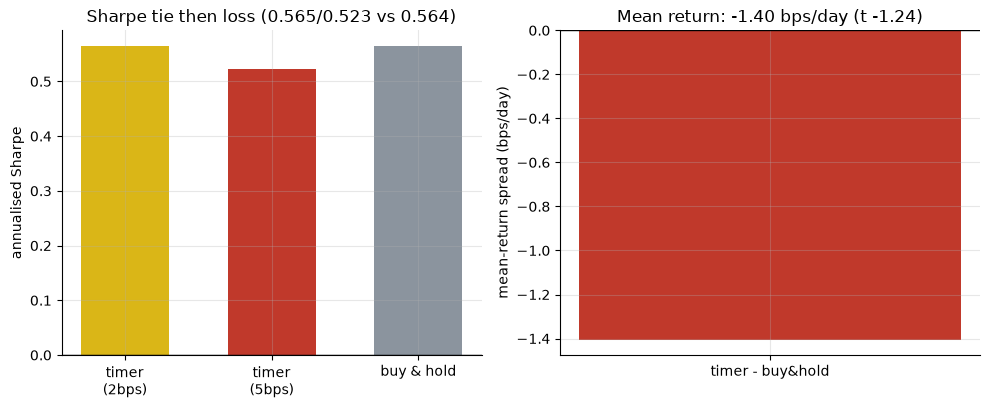

timer Sharpe 0.565 (5bps 0.523) | buy&hold 0.564 | 16.7 switches/yr | mean spread -1.40 bps/d (t -1.24)


In [6]:
if HAVE_REAL:
    ov = st.timing_overlay(DF, cost_bps=2.0); ov5 = st.timing_overlay(DF, cost_bps=5.0)
    ts, bs, sw = ov['timer_sharpe'], ov['bh_sharpe'], ov['switches_per_yr']
    sp, spt, ts5 = ov['spread_bps_day'], ov['spread_t'], ov5['timer_sharpe']
else:
    ts, bs, sw = 0.565, 0.564, 16.7
    sp, spt, ts5 = -1.4, -1.24, 0.523
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))
a1.bar(['timer\n(2bps)','timer\n(5bps)','buy & hold'], [ts, ts5, bs], color=[AMBER, RED, GREY], width=.6)
a1.set_ylabel('annualised Sharpe'); a1.set_title(f'Sharpe tie then loss ({ts:.3f}/{ts5:.3f} vs {bs:.3f})')
a1.axhline(0, c='k', lw=1)
a2.bar(['timer - buy&hold'], [sp], color=(RED if sp<0 else GREEN), width=.4)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('mean-return spread (bps/day)')
a2.set_title(f'Mean return: {sp:+.2f} bps/day (t {spt:+.2f})')
plt.tight_layout(); plt.show()
print(f'timer Sharpe {ts:.3f} (5bps {ts5:.3f}) | buy&hold {bs:.3f} | {sw:.1f} switches/yr | mean spread {sp:+.2f} bps/d (t {spt:+.2f})')

> 💡 In plain words: the timer's *Sharpe* tie is an illusion — it sits in cash ~52% of the time, trimming volatility, not adding return. On the honest metric (mean return) it **loses** 1.4 bps/day (*t* -1.24) while churning 16.7 round-trips a year, and at 5 bps/switch its Sharpe (0.523) falls *below* buy-and-hold (0.564). `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real *predictive* edge (`edge > 0`) of increasing strength — **while keeping the same contemporaneous inverse link on** (so the null exactly matches the real world: link present, forecast absent) — and watch the Q5−Q1 HAC *t* rise, averaged over 25 seeds.

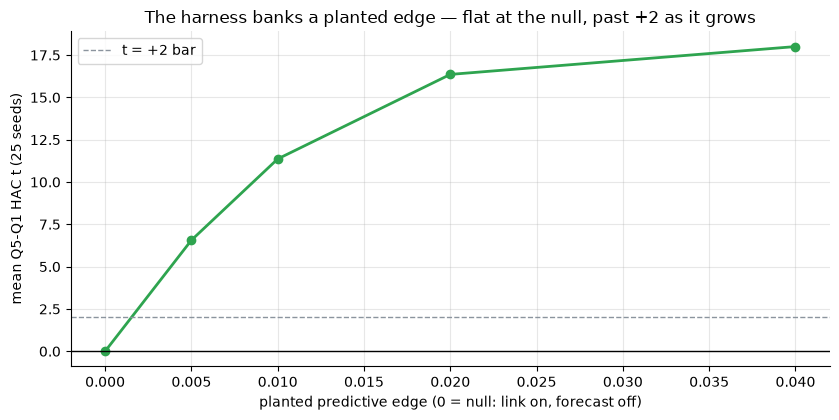

edge 0.000 -> mean spread +0.03%, mean HAC t +0.00
edge 0.005 -> mean spread +6.80%, mean HAC t +6.56
edge 0.010 -> mean spread +13.59%, mean HAC t +11.36
edge 0.020 -> mean spread +27.27%, mean HAC t +16.36
edge 0.040 -> mean spread +55.43%, mean HAC t +18.00


In [7]:
signals = [0.0, 0.005, 0.010, 0.020, 0.040]
res = [st.synthetic_mean_t(data, edge=a, n_seeds=25, horizon=21, n_days=3000) for a in signals]
ts = [r['mean_t'] for r in res]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(signals, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted predictive edge (0 = null: link on, forecast off)')
ax.set_ylabel('mean Q5-Q1 HAC t (25 seeds)')
ax.set_title('The harness banks a planted edge — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, r in zip(signals, res): print(f'edge {a:.3f} -> mean spread {r["mean_spread"]*100:+.2f}%, mean HAC t {r["mean_t"]:+.2f}')

The mean HAC *t* is ≈ 0 at the null (no false positive, even though the inverse *link* is present) and climbs far past +2 as the planted *forecast* edge grows — so the engine is a faithful detector. The real-tape null is therefore a statement about **this tape**: gold co-moves with real yields but is not timed by their trend. For gold from other angles, see [640 Gold-Overnight](../../640-gold-overnight/) and [649 Gold-Seasonality](../../649-gold-seasonality/).